<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

На втором этапе мы проводим первичный анализ собранных данных, чтобы понять их структуру, выявить аномалии и сформулировать первые гипотезы о связи новостей и рынка.

## Загрузка данных

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка графиков
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'

# Загружаем новости
df_news = pd.read_csv(f'{PROJECT_DIR}/data/raw/news/news_clean.csv')
df_news['date'] = pd.to_datetime(df_news['date'])

# Загружаем котировки
TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX', 'X5']
market_data = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/raw/market/{ticker}.csv', index_col=0)
    df.index = pd.to_datetime(df.index)
    market_data[ticker] = df

print(f'Новостей: {len(df_news):,}')
print(f'Тикеров: {len(market_data)}')

Mounted at /content/drive
Новостей: 74,155
Тикеров: 7


## Анализ новостей

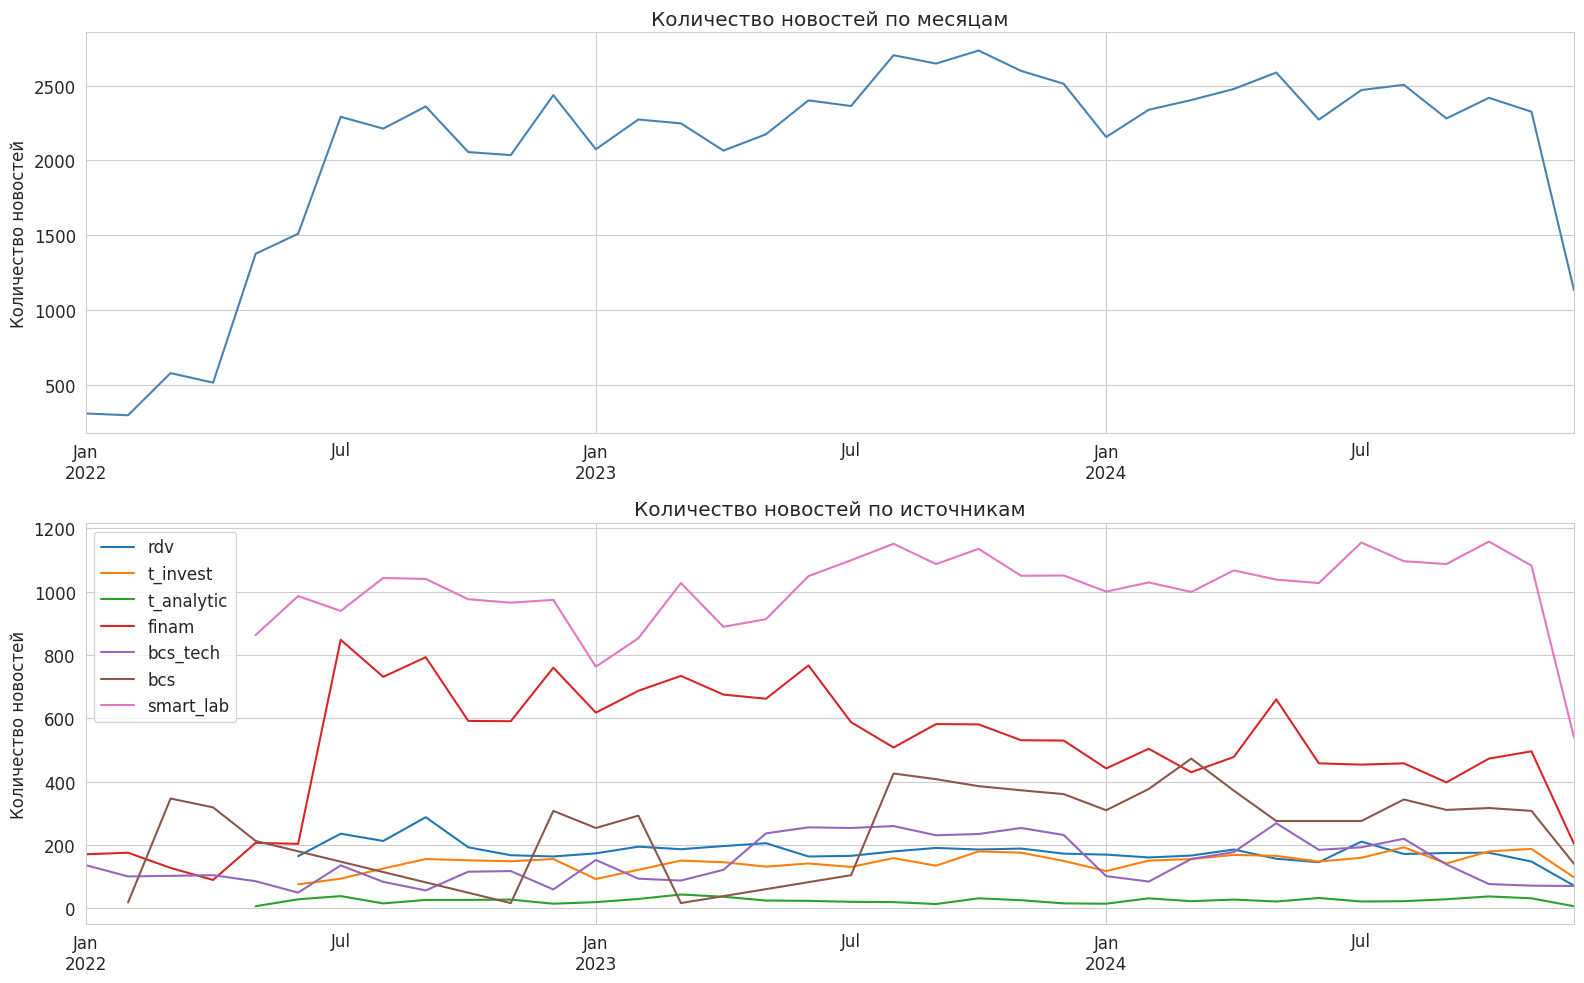

In [2]:
# Количество новостей по месяцам
df_news['year_month'] = df_news['date'].dt.to_period('M')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# График 1 — новости по месяцам
monthly = df_news.groupby('year_month').size()
monthly.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Количество новостей по месяцам')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество новостей')

# График 2 — новости по источникам по месяцам
for source in df_news['source'].unique():
    data = df_news[df_news['source'] == source].groupby('year_month').size()
    data.plot(ax=axes[1], label=source)
axes[1].set_title('Количество новостей по источникам')
axes[1].set_xlabel('')
axes[1].set_ylabel('Количество новостей')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/news_timeline.png', dpi=150)
plt.show()

Распределение новостей по источникам оказалось неравномерным

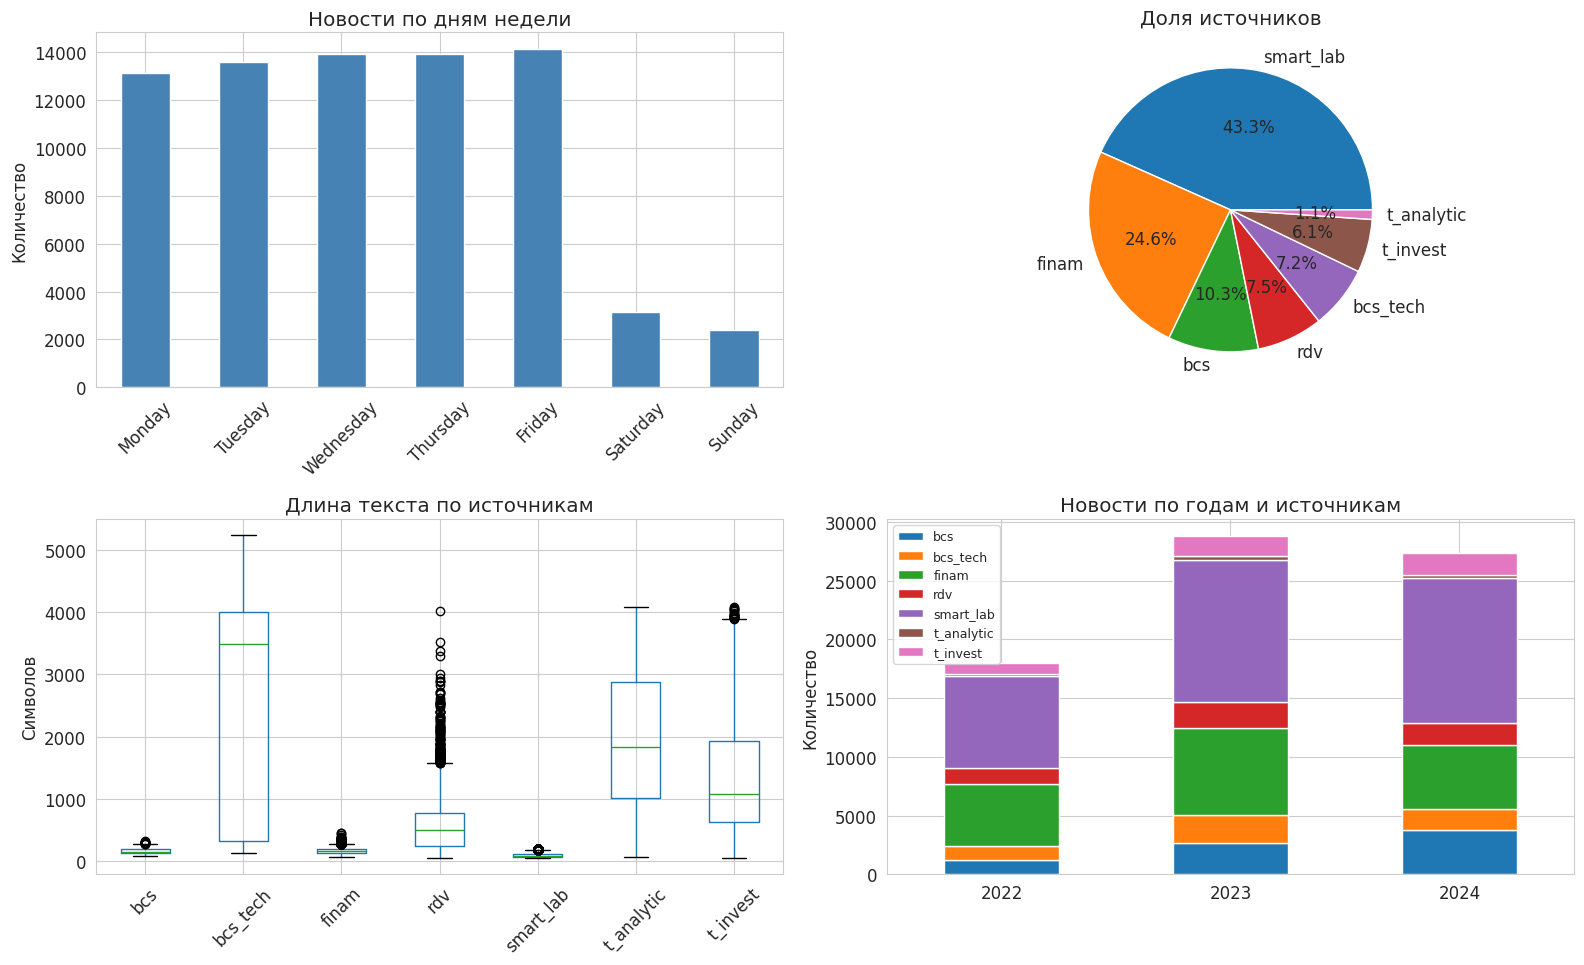

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# График 1 — новости по дням недели
df_news['weekday'] = df_news['date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df_news.groupby('weekday').size().reindex(weekday_order)
weekday_counts.plot(kind='bar', ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Новости по дням недели')
axes[0][0].set_xlabel('')
axes[0][0].set_ylabel('Количество')
axes[0][0].tick_params(axis='x', rotation=45)

# График 2 — доля источников
source_counts = df_news['source'].value_counts()
axes[0][1].pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%')
axes[0][1].set_title('Доля источников')

# График 3 — длина текста по источникам
df_news['text_len'] = df_news['full_text'].str.len()
df_news.boxplot(column='text_len', by='source', ax=axes[1][0])
axes[1][0].set_title('Длина текста по источникам')
axes[1][0].set_xlabel('')
axes[1][0].set_ylabel('Символов')
plt.sca(axes[1][0])
plt.xticks(rotation=45)

# График 4 — количество новостей по годам
df_news['year'] = df_news['date'].dt.year
year_counts = df_news.groupby(['year', 'source']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', ax=axes[1][1], stacked=True)
axes[1][1].set_title('Новости по годам и источникам')
axes[1][1].set_xlabel('')
axes[1][1].set_ylabel('Количество')
axes[1][1].tick_params(axis='x', rotation=0)
axes[1][1].legend(loc='upper left', fontsize=9)

plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/news_analysis.png', dpi=150)
plt.show()

Средняя длина текста составила 430 символов, что соответствует коротким новостным заметкам и постам из Telegram-каналов. Около 49.5% статей не имели заголовка — это характерно для Telegram-источников (RDV, T-Invest, SmartLab), где контент публикуется в формате постов без заголовков.

## Анализ рыночных данных

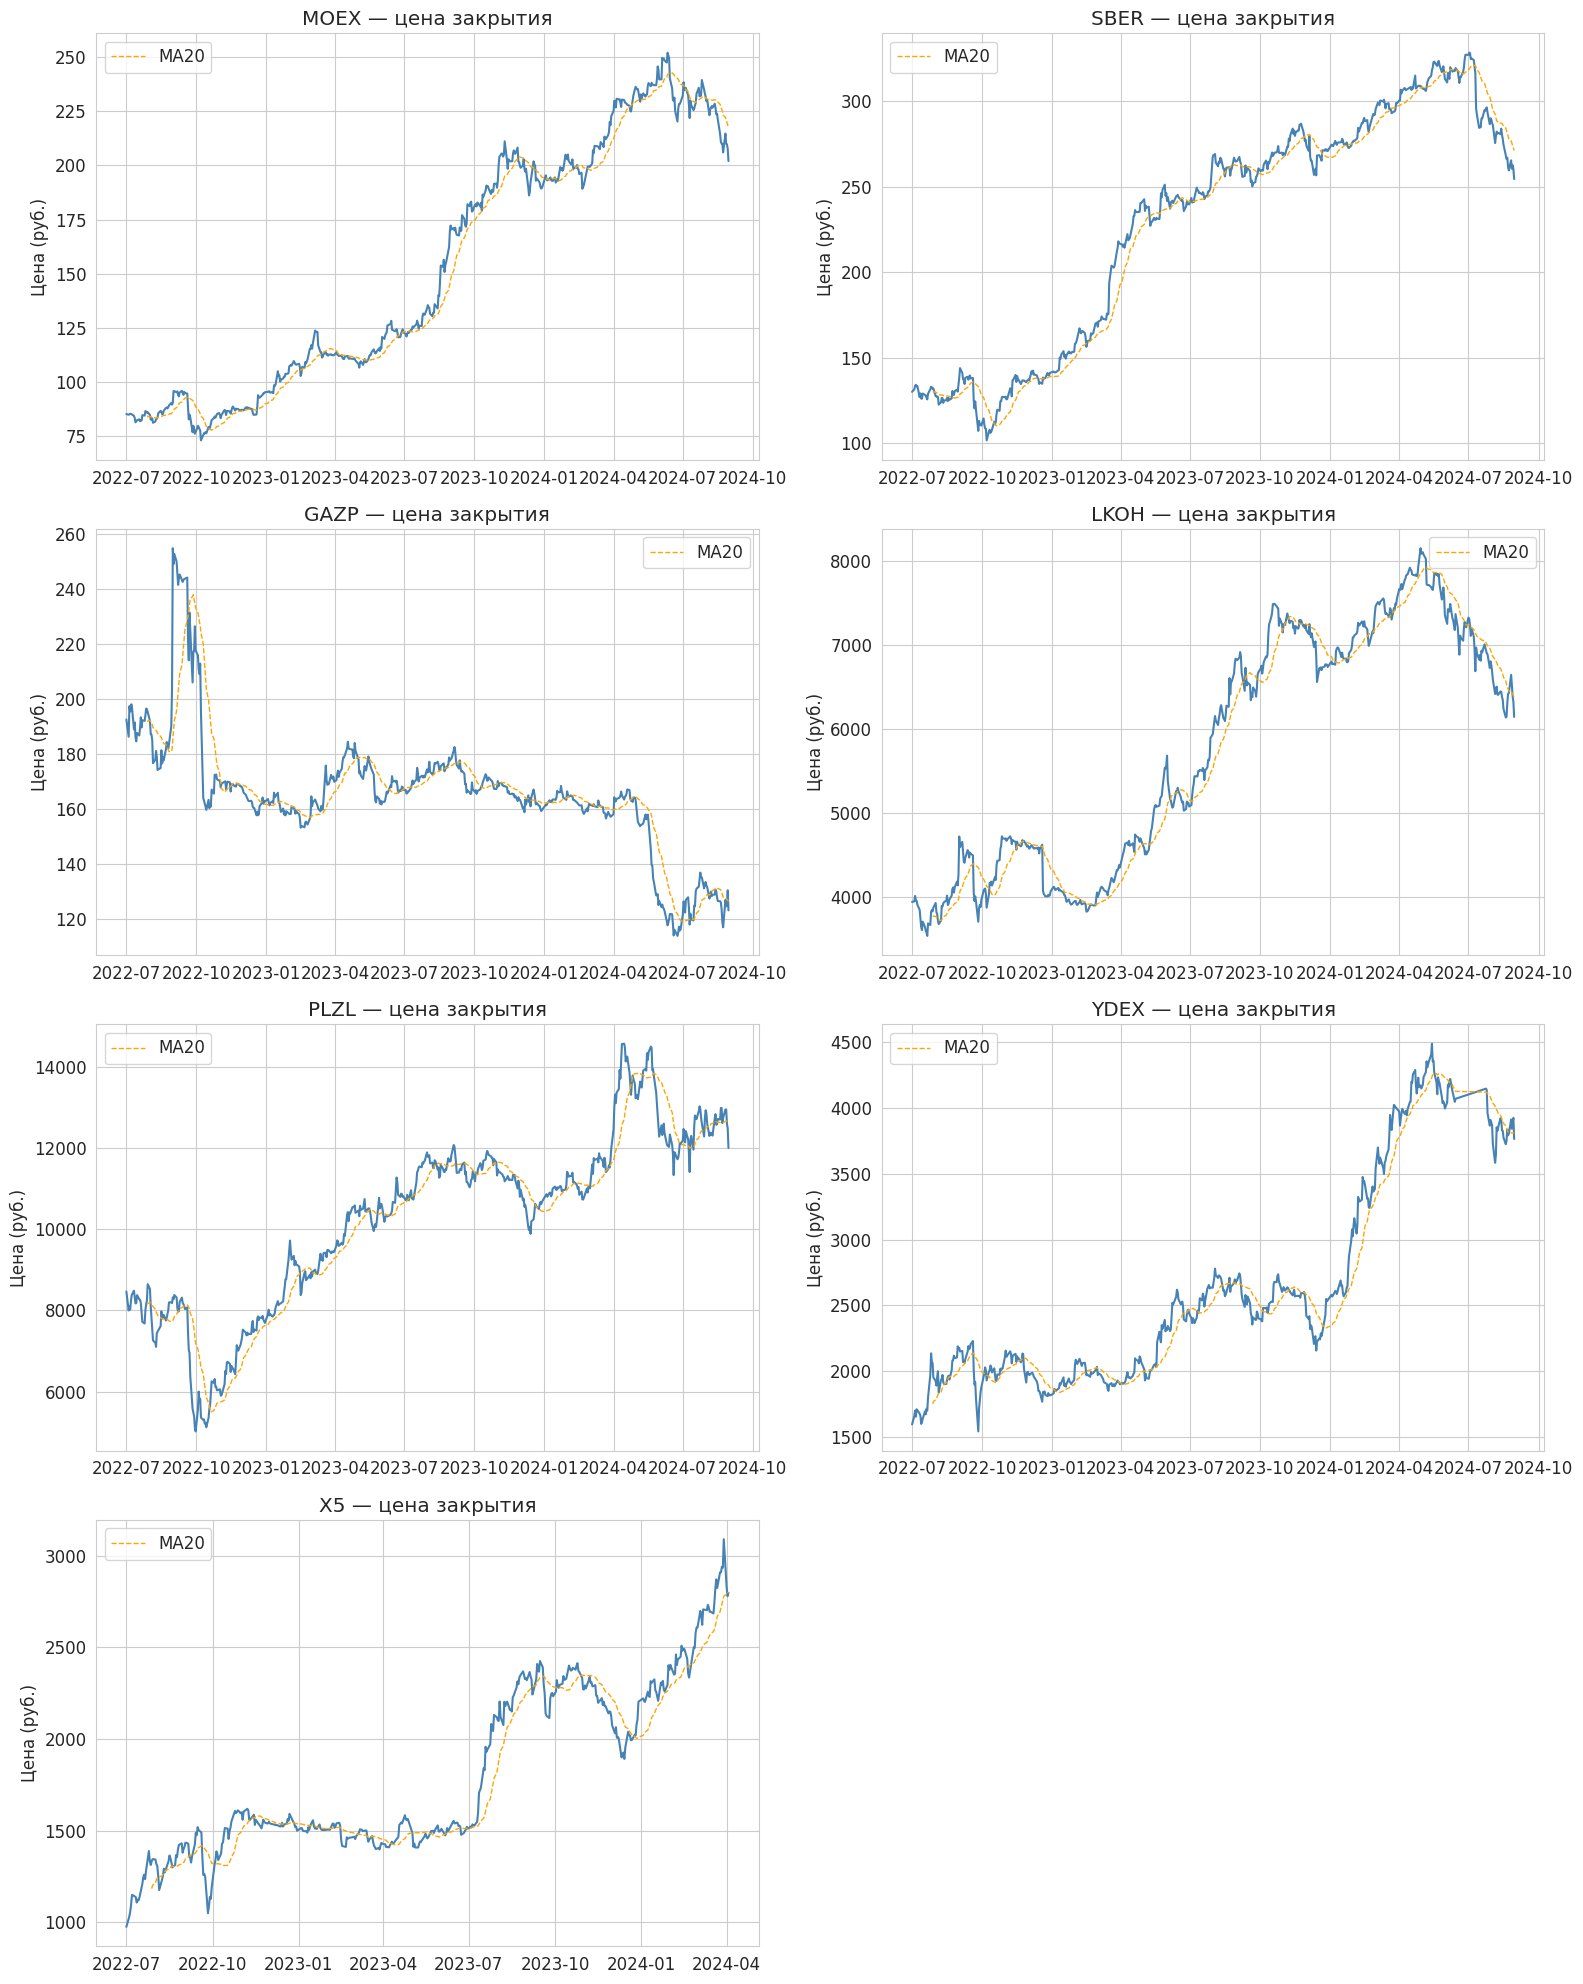

In [3]:
# Динамика цен всех инструментов
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, (ticker, df) in enumerate(market_data.items()):
    ax = axes[i]
    ax.plot(df.index, df['close'], color='steelblue', linewidth=1.5)
    ax.set_title(f'{ticker} — цена закрытия')
    ax.set_xlabel('')
    ax.set_ylabel('Цена (руб.)')

    # Добавляем скользящее среднее 20 дней
    ma20 = df['close'].rolling(20).mean()
    ax.plot(df.index, ma20, color='orange', linewidth=1, linestyle='--', label='MA20')
    ax.legend()

# Убираем лишний subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/market_prices.png', dpi=150)
plt.show()

Статистика дневной доходности по инструментам:

--- Статистика доходности (%) ---
          MOEX     SBER     GAZP     LKOH     PLZL     YDEX       X5
count  552.000  552.000  552.000  552.000  552.000  525.000  447.000
mean     0.170    0.136   -0.059    0.094    0.085    0.191    0.264
std      1.679    1.707    2.142    1.663    2.099    2.345    2.336
min     -8.086  -10.327  -16.018  -11.870  -12.465  -13.885  -16.034
25%     -0.639   -0.566   -0.810   -0.611   -0.947   -0.990   -0.872
50%      0.009    0.079   -0.103    0.012    0.028    0.053    0.038
75%      0.943    0.812    0.639    0.915    1.096    1.305    1.261
max      6.143   10.339   24.951   10.585   10.771   11.030   10.202


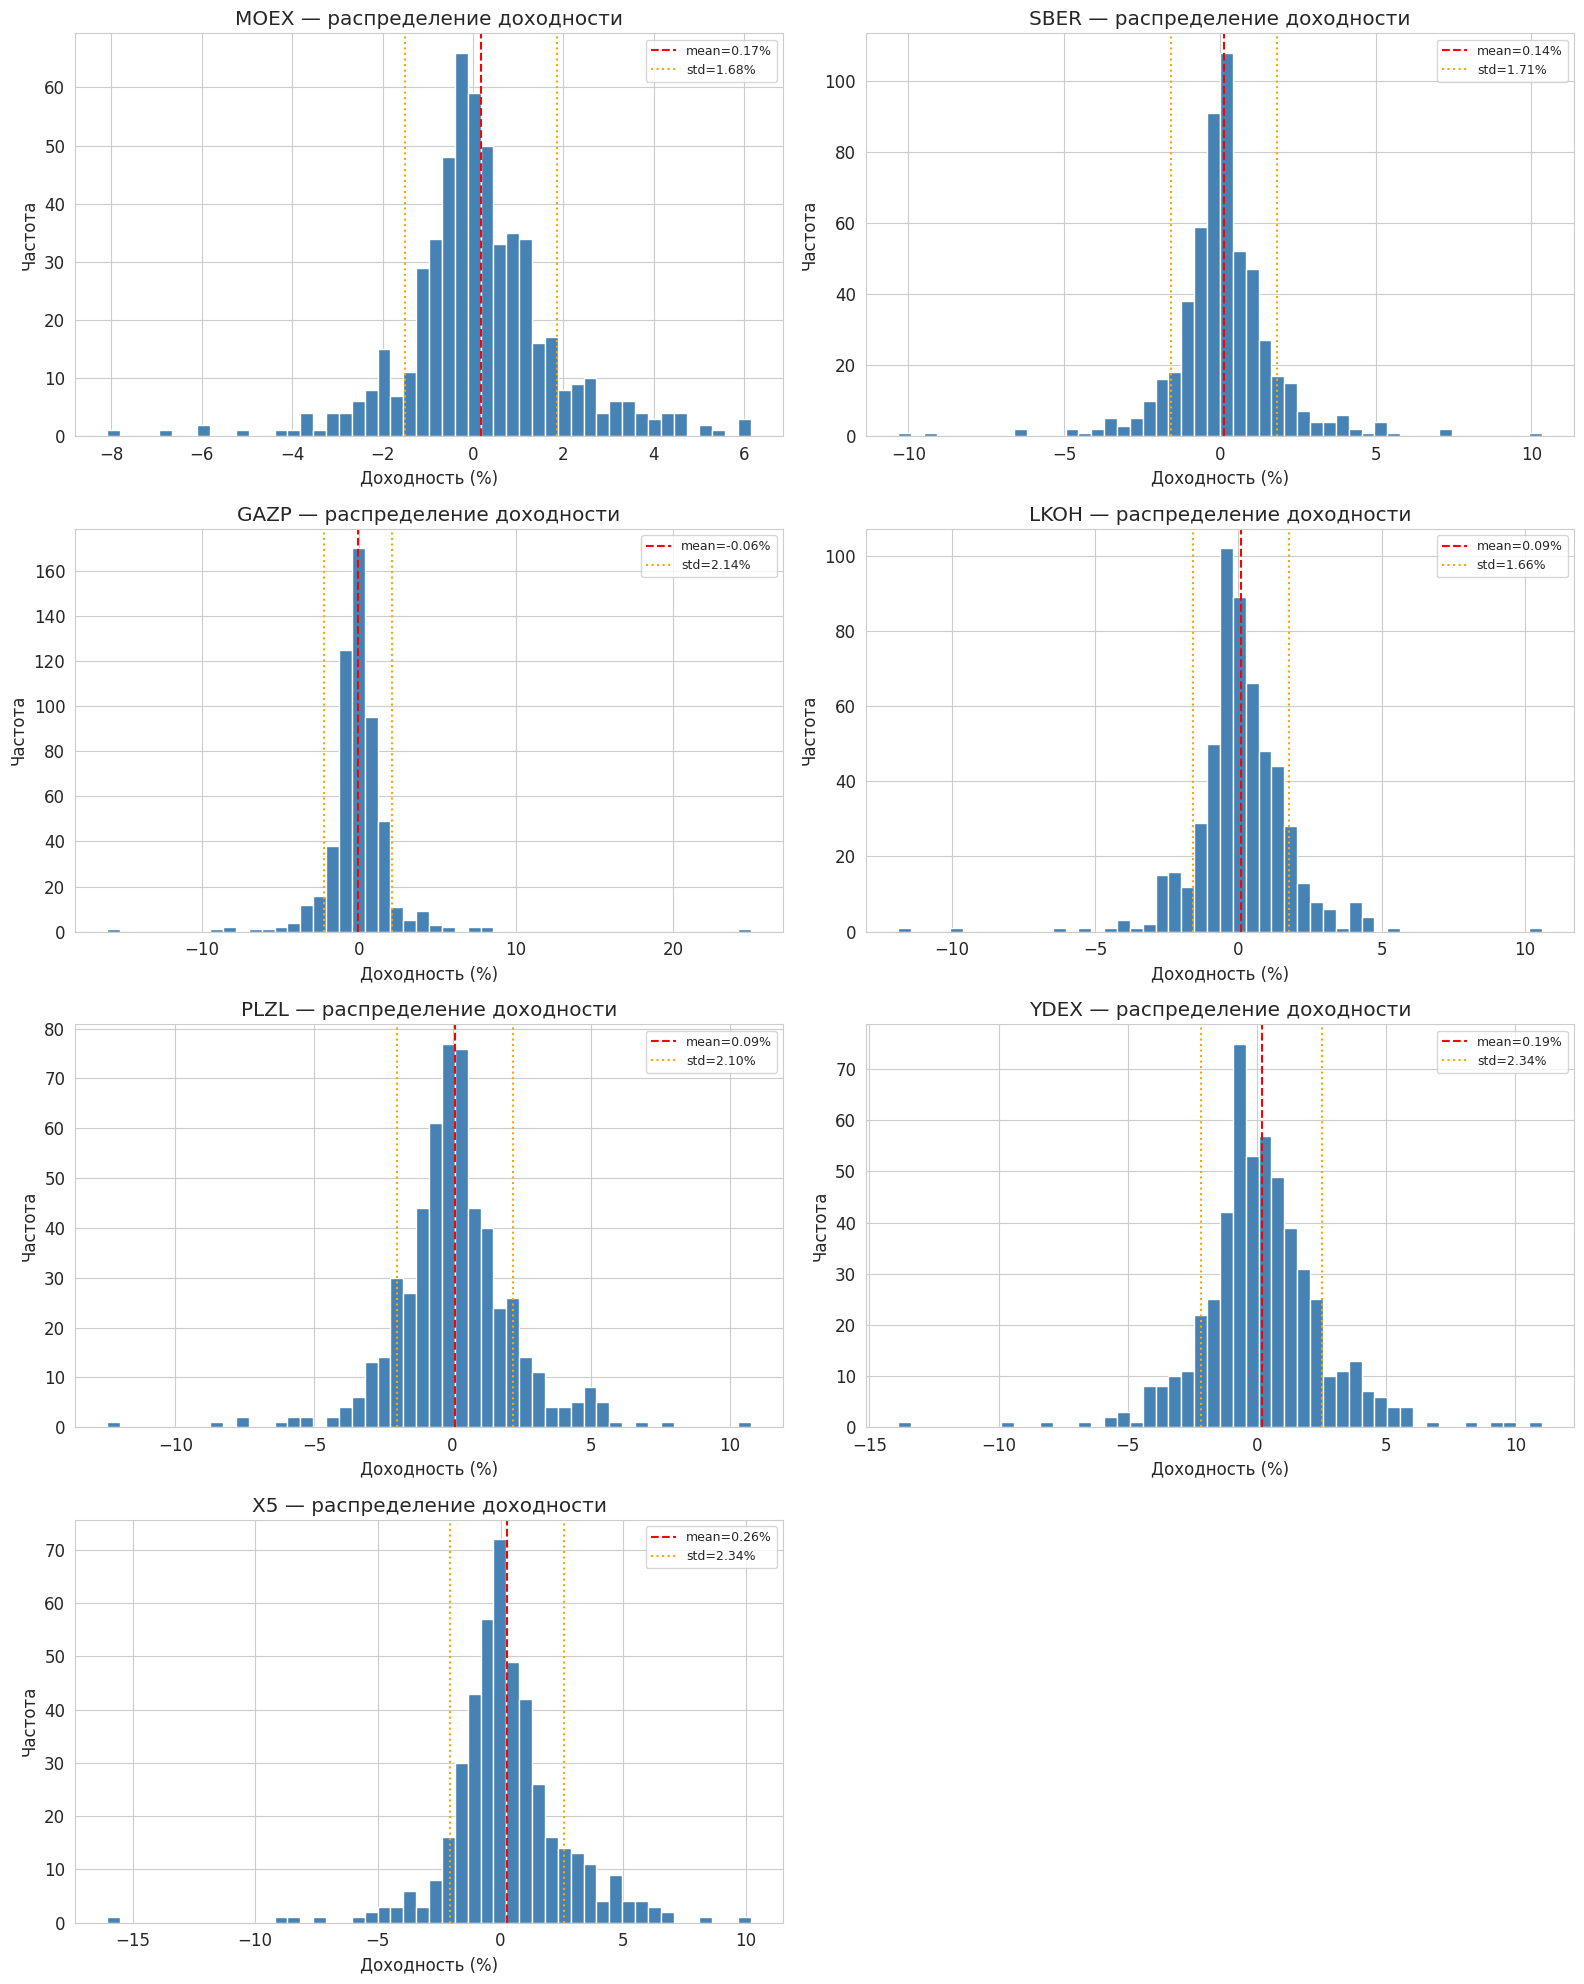

In [24]:
# Считаем дневную доходность для всех тикеров
returns = pd.DataFrame()

for ticker, df in market_data.items():
    returns[ticker] = df['close'].pct_change() * 100  # в процентах

print('--- Статистика доходности (%) ---')
print(returns.describe().round(3))

# График распределения доходностей
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes[i]
    returns[ticker].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{ticker} — распределение доходности')
    ax.set_xlabel('Доходность (%)')
    ax.set_ylabel('Частота')

    # Среднее и std
    mean = returns[ticker].mean()
    std = returns[ticker].std()
    ax.axvline(mean, color='red', linestyle='--', label=f'mean={mean:.2f}%')
    ax.axvline(mean + std, color='orange', linestyle=':', label=f'std={std:.2f}%')
    ax.axvline(mean - std, color='orange', linestyle=':')
    ax.legend(fontsize=9)

axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/returns_distribution.png', dpi=150)
plt.show()

Газпром — единственный инструмент с отрицательной средней доходностью за период (-0.06%). Это отражает реальную ситуацию: компания потеряла значительную долю европейского рынка сбыта, что негативно сказалось на котировках.

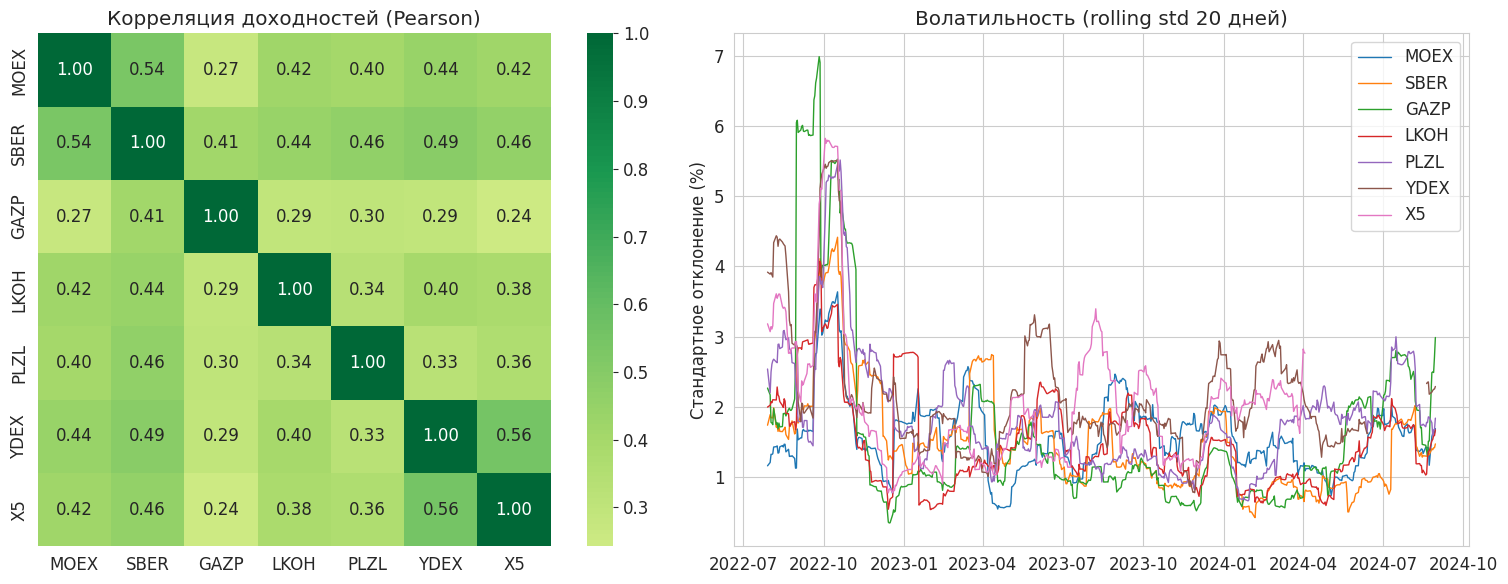

--- Корреляционная матрица ---
      MOEX  SBER  GAZP  LKOH  PLZL  YDEX    X5
MOEX  1.00  0.54  0.27  0.42  0.40  0.44  0.42
SBER  0.54  1.00  0.41  0.44  0.46  0.49  0.46
GAZP  0.27  0.41  1.00  0.29  0.30  0.29  0.24
LKOH  0.42  0.44  0.29  1.00  0.34  0.40  0.38
PLZL  0.40  0.46  0.30  0.34  1.00  0.33  0.36
YDEX  0.44  0.49  0.29  0.40  0.33  1.00  0.56
X5    0.42  0.46  0.24  0.38  0.36  0.56  1.00


In [5]:
 # Корреляционная матрица доходностей
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pearson корреляция
corr_matrix = returns.dropna().corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[0],
    square=True
)
axes[0].set_title('Корреляция доходностей (Pearson)')

# Волатильность — скользящее стандартное отклонение 20 дней
ax = axes[1]
for ticker in TICKERS:
    vol = returns[ticker].rolling(20).std()
    ax.plot(vol.index, vol, label=ticker, linewidth=1)
ax.set_title('Волатильность (rolling std 20 дней)')
ax.set_ylabel('Стандартное отклонение (%)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/correlation_volatility.png', dpi=150)
plt.show()

print('--- Корреляционная матрица ---')
print(corr_matrix.round(2))

## Анализ упоминаний компаний

Для каждого тикера был проведён поиск релевантных новостей по ключевым словам

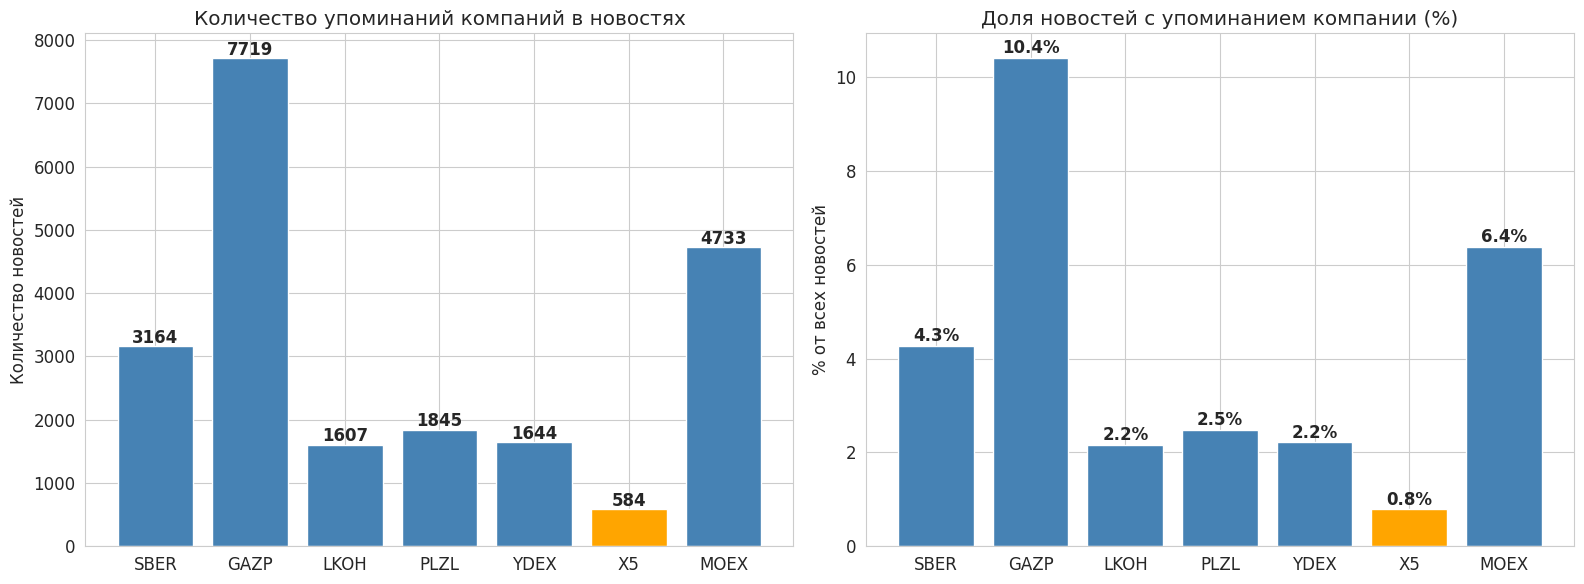

--- Упоминания компаний ---
GAZP: 7,719 новостей (10.4%)
MOEX: 4,733 новостей (6.4%)
SBER: 3,164 новостей (4.3%)
PLZL: 1,845 новостей (2.5%)
YDEX: 1,644 новостей (2.2%)
LKOH: 1,607 новостей (2.2%)
X5: 584 новостей (0.8%)


In [22]:
# Ключевые слова для каждой компании
company_keywords = {
    'SBER':  ['сбер', 'сбербанк', 'sber', 'греф'],
    'GAZP':  ['газпром', 'gazprom', 'газ'],
    'LKOH':  ['лукойл', 'lukoil', 'лукойла'],
    'PLZL':  ['полюс', 'polyus', 'золото', 'gold'],
    'YDEX':  ['яндекс', 'yandex', 'ydex'],
    'X5':    ['x5', 'пятёрочка', 'пятерочка', 'перекрёсток', 'перекресток', 'чижик', 'X5 Retail Group', 'FIVE'],
    'MOEX':  ['московская биржа', 'мосбиржа', 'moex', 'imoex'],
}

# Считаем упоминания
df_news['full_text_lower'] = df_news['full_text'].str.lower()

mentions = {}
for ticker, keywords in company_keywords.items():
    mask = df_news['full_text_lower'].str.contains('|'.join(keywords), na=False)
    mentions[ticker] = mask.sum()

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 — абсолютное количество упоминаний
tickers = list(mentions.keys())
counts = list(mentions.values())
colors = ['steelblue' if c > 1000 else 'orange' if c > 300 else 'red' for c in counts]

axes[0].bar(tickers, counts, color=colors)
axes[0].set_title('Количество упоминаний компаний в новостях')
axes[0].set_ylabel('Количество новостей')
for i, (ticker, count) in enumerate(zip(tickers, counts)):
    axes[0].text(i, count + 50, str(count), ha='center', fontweight='bold')

# График 2 — доля от всех новостей
pct = [c / len(df_news) * 100 for c in counts]
axes[1].bar(tickers, pct, color=colors)
axes[1].set_title('Доля новостей с упоминанием компании (%)')
axes[1].set_ylabel('% от всех новостей')
for i, (ticker, p) in enumerate(zip(tickers, pct)):
    axes[1].text(i, p + 0.1, f'{p:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/company_mentions.png', dpi=150)
plt.show()

print('--- Упоминания компаний ---')
for ticker, count in sorted(mentions.items(), key=lambda x: -x[1]):
    pct = count / len(df_news) * 100
    print(f'{ticker}: {count:,} новостей ({pct:.1f}%)')

Газпром оказался наиболее часто упоминаемой компанией, что объясняется высоким вниманием СМИ к газовому сектору в период 2022–2024 годов на фоне санкционного давления и изменения маршрутов экспорта.

Можно увидеть, что упоминания X5 минимальны. Попробуем разобраться в этом.

In [23]:
# Смотрим примеры новостей где встречается x5
mask = df_news['full_text_lower'].str.contains('|'.join(company_keywords['X5']), na=False)
df_x5_news = df_news[mask][['source', 'date', 'full_text']].head(20)

for i, row in df_x5_news.iterrows():
    print(f"[{row['source']}] {row['date'].date()}")
    print(row['full_text'])
    print('---')

[rdv] 2024-08-15
"Главное к открытию четверга (15.08): #брифинг  Значение индекса ЖиС: 46 (спокойствие). Подробнее об индексе здесь.  11.94 ₽/¥, 79.44 $/барр.  Softline приобрела контроль в одном из IT-подразделений Газпромбанка.  Российские лесопромышленные компании в первом полугодии выплатили государству за пользование лесами более 38 млрд руб., что на 10% больше прошлогоднего уровня.  События сегодня: (1) Финансовые результаты за 2кв24: Совкомбанк (SVCB), X5 Group (FIVE), Softline (SOFL). (2) Статистика по рынку труда в США.  Что влияет на рынки в ближайшие 5 дней?  Доступно членам @RDVPREMIUMbot   "
---
[rdv] 2024-07-16
"Главное к открытию вторника (16.07):  #брифинг  Значение индекса ЖиС: 37 (страх). Подробнее об индексе здесь.  12.08 ₽/¥, 83.92 $/барр.  Bloomberg: Великобритания планирует на этой неделе обратиться к группе европейских стран с «призывом к действию», направленного против «теневого флота нефтяных танкеров, который Россия использует для обхода международных санкций»

Тикер X5 (X5 Retail Group) был исключён из анализа по двум причинам: недостаточное количество котировок (448 дней из-за приостановки торгов на бирже, данные заканчиваются апрелем 2024) и малое число новостных упоминаний (менее 1% от общего объёма).

## Первичная корреляция

На данном этапе была проверена простейшая гипотеза: связано ли количество новостей с доходностью рынка.

Дней с новостями И котировками: 553
Период: 2022-07-01 → 2024-08-30


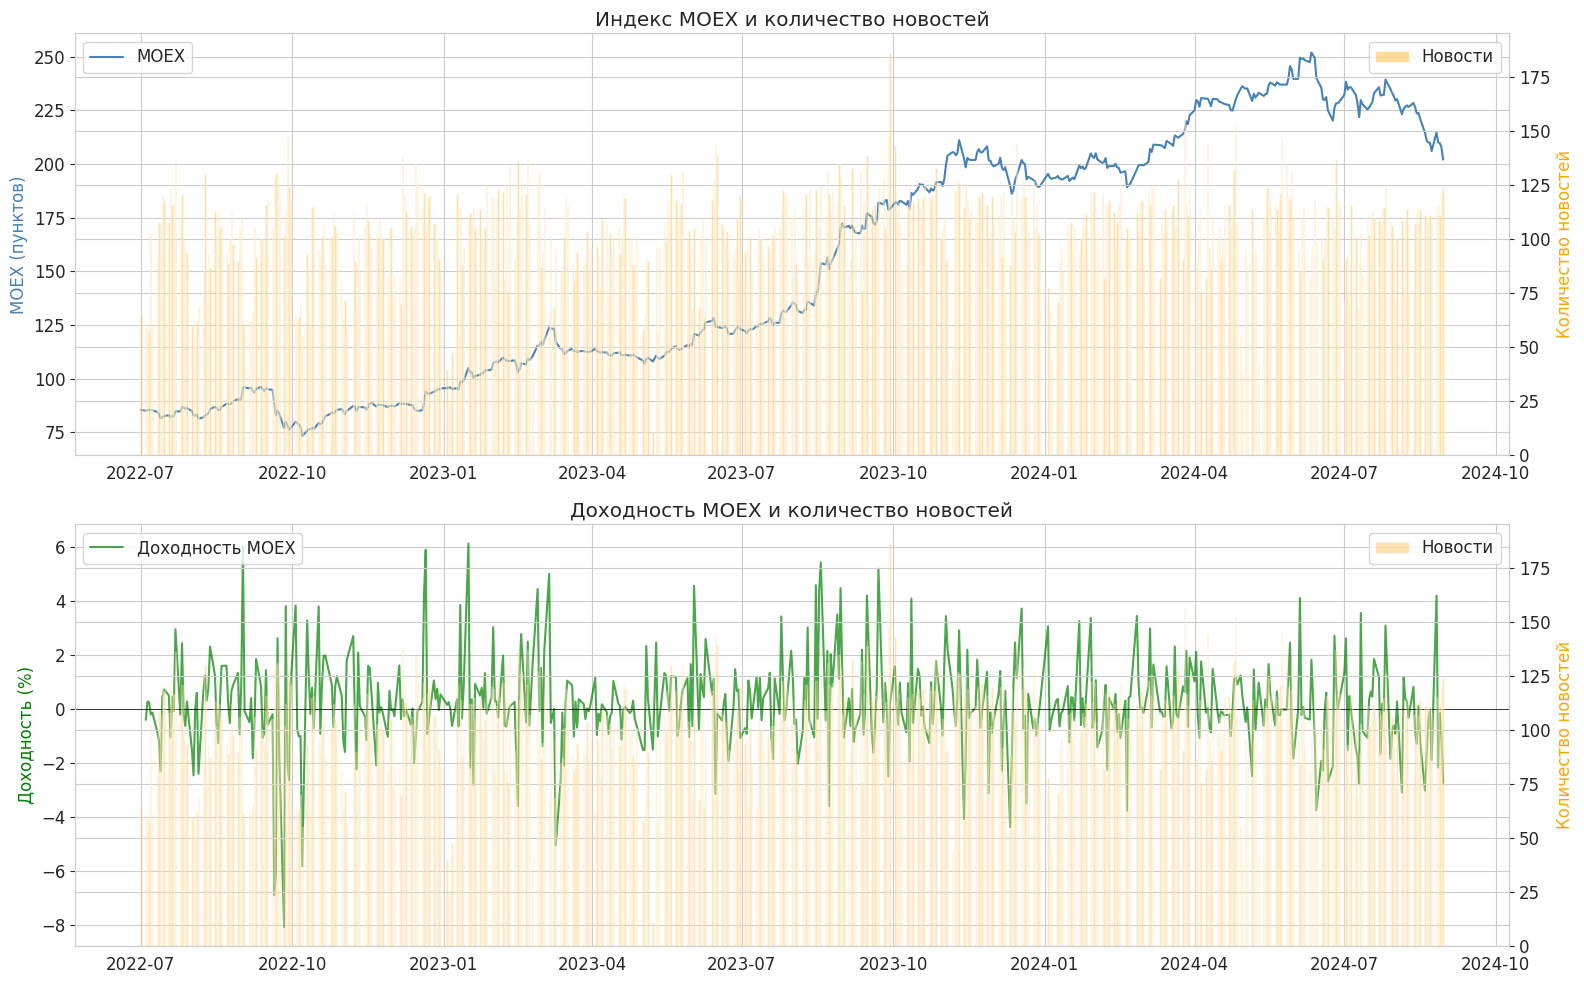


Корреляция: количество новостей vs доходность MOEX
Pearson:  0.052
Spearman: 0.060


In [7]:
# Считаем количество новостей по дням
news_daily = df_news.groupby('date').agg(
    news_count=('full_text', 'count'),
    avg_text_len=('text_len', 'mean')
).reset_index()
news_daily['date'] = pd.to_datetime(news_daily['date'])

# Берём MOEX как основной индикатор рынка
df_moex = market_data['MOEX'].copy()
df_moex['return'] = df_moex['close'].pct_change() * 100
df_moex = df_moex.reset_index()
df_moex.columns = ['date'] + list(df_moex.columns[1:])

# Объединяем
df_merged = pd.merge(df_moex, news_daily, on='date', how='inner')

print(f'Дней с новостями И котировками: {len(df_merged)}')
print(f'Период: {df_merged["date"].min().date()} → {df_merged["date"].max().date()}')

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# График 1 — MOEX и количество новостей
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_merged['date'], df_merged['close'], color='steelblue', label='MOEX')
ax2.bar(df_merged['date'], df_merged['news_count'], color='orange', alpha=0.4, label='Новости')
ax1.set_title('Индекс MOEX и количество новостей')
ax1.set_ylabel('MOEX (пунктов)', color='steelblue')
ax2.set_ylabel('Количество новостей', color='orange')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# График 2 — доходность MOEX и количество новостей
ax3 = axes[1]
ax4 = ax3.twinx()
ax3.plot(df_merged['date'], df_merged['return'], color='green', alpha=0.7, label='Доходность MOEX')
ax3.axhline(0, color='black', linewidth=0.5)
ax4.bar(df_merged['date'], df_merged['news_count'], color='orange', alpha=0.3, label='Новости')
ax3.set_title('Доходность MOEX и количество новостей')
ax3.set_ylabel('Доходность (%)', color='green')
ax4.set_ylabel('Количество новостей', color='orange')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/news_vs_market.png', dpi=150)
plt.show()

print(f'\nКорреляция: количество новостей vs доходность MOEX')
print(f'Pearson:  {df_merged["news_count"].corr(df_merged["return"]):.3f}')
print(f'Spearman: {df_merged["news_count"].corr(df_merged["return"], method="spearman"):.3f}')

Корреляция Pearson между количеством новостей и доходностью MOEX составила r = 0.052, Spearman r = 0.060. Результат показал, что количество новостей само по себе практически не связано с доходностью. Это подтвердило необходимость анализа тональности новостей, а не только их количества.

## Сохранение итогов и выводы

In [19]:
import json

# Сохраняем финальные ключевые слова
with open(f'{PROJECT_DIR}/data/processed/company_keywords.json', 'w', encoding='utf-8') as f:
    json.dump(company_keywords_final, f, ensure_ascii=False, indent=2)

# Сохраняем список тикеров для анализа
with open(f'{PROJECT_DIR}/data/processed/analysis_tickers.json', 'w', encoding='utf-8') as f:
    json.dump(ANALYSIS_TICKERS, f, ensure_ascii=False, indent=2)

print('Сохранено: company_keywords.json')
print('Сохранено: analysis_tickers.json')

print(f'Инструменты для анализа: {ANALYSIS_TICKERS}')
print(f'X5 исключён: мало котировок (до апреля 2024) и мало новостей')

Сохранено: company_keywords.json
Сохранено: analysis_tickers.json
Инструменты для анализа: ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']
X5 исключён: мало котировок (до апреля 2024) и мало новостей


In [20]:
print('--- ИТОГ EDA (Ноутбук 02) ---')
print()
print('--- НОВОСТИ ---')
print(f'Всего новостей:        {len(df_news):,}')
print(f'Период:                {df_news["date"].min().date()} → {df_news["date"].max().date()}')
print(f'Источников:            {df_news["source"].nunique()}')
print(f'Средняя длина текста:  {df_news["text_len"].mean():.0f} символов')
print()
print('--- РЫНОК ---')
for ticker, df in market_data.items():
    ret = df['close'].pct_change() * 100
    print(f'{ticker}: доходность mean={ret.mean():.2f}%, std={ret.std():.2f}%')
print()
print('--- ПЕРЕСЕЧЕНИЕ ---')
print(f'Дней с новостями и котировками: {len(df_merged)}')
print()
print('--- КЛЮЧЕВЫЕ ВЫВОДЫ ---')
print('1. Количество новостей слабо коррелирует с доходностью (r=0.05)')
print('2. ГАЗПРОМ наименее коррелирован с рынком (0.27) — специфика сектора')
print('3. SBER наиболее коррелирован с MOEX (0.54) — системообразующий банк')
print('4. Удаляем тикер X5, для него недостаточно новостей на общем фоне')
print('5. Для выявления влияния новостей нужен анализ ТОНАЛЬНОСТИ → ноутбук 03')

--- ИТОГ EDA (Ноутбук 02) ---

--- НОВОСТИ ---
Всего новостей:        74,155
Период:                2022-01-02 → 2024-12-16
Источников:            7
Средняя длина текста:  430 символов

--- РЫНОК ---
MOEX: доходность mean=0.17%, std=1.68%
SBER: доходность mean=0.14%, std=1.71%
GAZP: доходность mean=-0.06%, std=2.14%
LKOH: доходность mean=0.09%, std=1.66%
PLZL: доходность mean=0.09%, std=2.10%
YDEX: доходность mean=0.19%, std=2.34%
X5: доходность mean=0.26%, std=2.34%

--- ПЕРЕСЕЧЕНИЕ ---
Дней с новостями и котировками: 553

--- КЛЮЧЕВЫЕ ВЫВОДЫ ---
1. Количество новостей слабо коррелирует с доходностью (r=0.05)
2. ГАЗПРОМ наименее коррелирован с рынком (0.27) — специфика сектора
3. SBER наиболее коррелирован с MOEX (0.54) — системообразующий банк
4. Удаляем тикер X5, для него недостаточно новостей на общем фоне
5. Для выявления влияния новостей нужен анализ ТОНАЛЬНОСТИ → ноутбук 03
